# Step 1:  Load & Clean Historical Stock Data 

In [10]:
import pandas as pd
import numpy as np

# Load Excel file
xls = pd.ExcelFile("data/NEPSE_data.xlsx")

# Combine all sheets into one DataFrame with 'date'
df_all = []
for sheet in xls.sheet_names:
    df = xls.parse(sheet)
    df['date'] = sheet  # Add sheet name as date
    df_all.append(df)

# Combine all into one
df_stock = pd.concat(df_all, ignore_index=True)

# Clean numeric columns
numeric_cols = [
    'Open', 'High', 'Low', 'Close', 'LTP', 'VWAP', 'Vol', 'Prev. Close',
    'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %',
    '120 Days', '180 Days', '52 Weeks High', '52 Weeks Low'
]

for col in numeric_cols:
    df_stock[col] = (
        df_stock[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .replace('-', np.nan)
        .astype(float)
    )

# Convert 'date' to datetime
df_stock['date'] = pd.to_datetime(df_stock['date'], format='%Y_%m_%d')

# Sort by symbol and date
df_stock.sort_values(by=['Symbol', 'date'], inplace=True)
df_stock.reset_index(drop=True, inplace=True)

# ✅ Done
print("✅ Step 1 complete. Stock data shape:", df_stock.shape)
print(df_stock[['Symbol', 'date', 'Close']].head())


✅ Step 1 complete. Stock data shape: (163563, 25)
   Symbol       date  Close
0  ACLBSL 2024-03-05  608.0
1  ACLBSL 2024-03-06  609.5
2  ACLBSL 2024-03-07  612.0
3  ACLBSL 2024-03-08  612.0
4  ACLBSL 2024-03-09  612.0


# Step 2: Load & Clean NEPSE Index Data (nepse_indices_all_pages.csv)

In [3]:
# Load the NEPSE index CSV
df_index = pd.read_csv("C:/My projects/Nepsevalue.csv")

# Convert 'Date' column to datetime
df_index['date'] = pd.to_datetime(df_index['Date'], dayfirst=True)


# Keep only date and NEPSE index (Close column)
df_index = df_index[['date', 'Close']]
df_index.rename(columns={'Close': 'NEPSE Index'}, inplace=True)

# ✅ Done
print("✅ Step 2 complete. Index data shape:", df_index.shape)
print(df_index.head())


✅ Step 2 complete. Index data shape: (231, 2)
        date NEPSE Index
0 2025-08-04    2,875.36
1 2025-08-03    2,858.90
2 2025-07-31    2,922.63
3 2025-07-30    2,954.14
4 2025-07-29    3,002.07


# Step 3: Merge Stock Data with NEPSE Index Data

In [4]:
# Merge stock data with NEPSE index data on 'date'
df_merged = pd.merge(df_stock, df_index, on='date', how='left')

# Drop any rows where NEPSE Index is missing
df_merged.dropna(subset=['NEPSE Index'], inplace=True)

# Sort by Symbol and date again after merge
df_merged.sort_values(by=['Symbol', 'date'], inplace=True)
df_merged.reset_index(drop=True, inplace=True)

# ✅ Done
print("✅ Step 3 complete. Merged data shape:", df_merged.shape)
print(df_merged[['Symbol', 'date', 'Close', 'NEPSE Index']].head())

df_merged.to_csv("merged_stock_with_index1.csv", index=False)
print("✅ Step 4 complete. Merged data saved as 'merged_stock_with_index.csv'")

✅ Step 3 complete. Merged data shape: (73067, 26)
   Symbol       date   Close NEPSE Index
0  ACLBSL 2024-08-05  1193.0    2,796.38
1  ACLBSL 2024-08-06  1200.0    2,651.32
2  ACLBSL 2024-08-07  1294.0    2,759.67
3  ACLBSL 2024-08-08  1230.2    2,766.38
4  ACLBSL 2024-08-11  1270.0    2,860.84
✅ Step 4 complete. Merged data saved as 'merged_stock_with_index.csv'


# Step 4: Feature Engineering

In [5]:
# Create lag features for previous day’s values
df_merged['Prev_Close'] = df_merged.groupby('Symbol')['Close'].shift(1)
df_merged['Prev_VWAP'] = df_merged.groupby('Symbol')['VWAP'].shift(1)

# Moving averages
df_merged['MA5'] = df_merged.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=5).mean())
df_merged['MA10'] = df_merged.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=10).mean())

# Daily price change
df_merged['Close_Change'] = df_merged['Close'] - df_merged['Prev_Close']
df_merged['Close_Change_%'] = (df_merged['Close_Change'] / df_merged['Prev_Close']) * 100

# Drop rows with missing values (due to lag/rolling)
df_merged.dropna(inplace=True)
df_merged.reset_index(drop=True, inplace=True)

# ✅ Done
print("✅ Step 4 complete. Feature engineered data shape:", df_merged.shape)
print(df_merged[['Symbol', 'date', 'Close', 'Prev_Close', 'MA5', 'Close_Change_%', 'NEPSE Index']].head())


✅ Step 4 complete. Feature engineered data shape: (27036, 32)
   Symbol       date    Close  Prev_Close       MA5  Close_Change_%  \
0  ACLBSL 2025-03-27  1089.65     1048.00  1057.414        3.974237   
1  ACLBSL 2025-03-30  1105.00     1089.65  1068.426        1.408709   
2  ACLBSL 2025-04-01  1083.49     1105.00  1073.104       -1.946606   
3  ACLBSL 2025-04-02  1097.34     1083.49  1084.696        1.278277   
4  ACLBSL 2025-04-03  1080.24     1097.34  1091.144       -1.558314   

  NEPSE Index  
0    2,663.30  
1    2,693.12  
2    2,676.17  
3    2,700.04  
4    2,703.39  


# Step 5: Prepare Dataset for Model Training

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

# Set target: next day's Close
df_merged['Target_Close'] = df_merged.groupby('Symbol')['Close'].shift(-1)

# Drop rows with missing target
df_merged.dropna(subset=['Target_Close'], inplace=True)

# Define input features
features = [
    'Prev_Close', 'Prev_VWAP', 'MA5', 'MA10',
    'Close_Change', 'Close_Change_%', 'NEPSE Index'
]

# Clean feature columns: remove commas and convert to float
for col in features:
    df_merged[col] = (
        df_merged[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .replace('-', pd.NA)
        .astype(float)
    )

# Scale features
feature_scaler = RobustScaler()
target_scaler = RobustScaler()
X_scaled = pd.DataFrame(feature_scaler.fit_transform(df_merged[features]), columns=features)
# Target
y_scaled = target_scaler.fit_transform(df_merged[['Target_Close']]).ravel()

# Train/test split
X_train, X_test, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled, y_scaled, test_size=0.2, shuffle=False
)


print("✅ Step 5 complete:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


✅ Step 5 complete:
X_train shape: (21323, 7)
X_test shape: (5331, 7)


# Step 6: Train the Model using XGBoost

In [7]:
from xgboost import XGBRegressor

# Create the XGBoost model with regularization
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42
)

# Train the model
model.fit(X_train, y_train_scaled)





,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Step 7: Model Evaluation

✅ Step 7: Evaluation Complete
Mean Squared Error: 13421747.26
R² Score: 0.5679


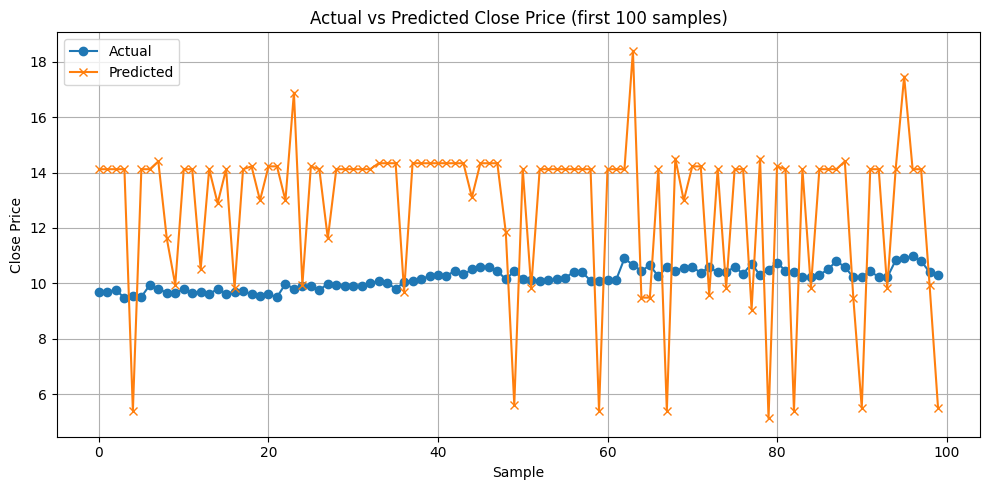

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ---- Predict for all rows of the chosen stock ----
sample_symbol = "UPPER"
sample_df = df[df["Symbol"] == sample_symbol].copy()

# Scale features of this stock
sample_scaled = scaler.transform(sample_df[features_to_use])

# Predict
sample_df["Prediction"] = xgb_regressor.predict(sample_scaled)

# ---- Evaluation on this stock only ----
mse = mean_squared_error(sample_df["Close"], sample_df["Prediction"])
r2 = r2_score(sample_df["Close"], sample_df["Prediction"])
mae = mean_absolute_error(sample_df["Close"], sample_df["Prediction"])

print("\n✅ Evaluation for:", sample_symbol)
print(f"MSE:  {mse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

# ---- Plot (SAME STYLE as your screenshot) ----
plt.figure(figsize=(14, 6))
plt.plot(sample_df["date"], sample_df["Close"], label=f"Actual Price for {sample_symbol}")
plt.plot(sample_df["date"], sample_df["Prediction"], label=f"Predicted Price for {sample_symbol}", linestyle="--")
plt.title(f"Actual vs Predicted Close Price for {sample_symbol}")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Step 8: Prediction

In [21]:

import numpy as np
import joblib

model = joblib.load("xgb_model.pkl")
scaler = joblib.load("scaler.pkl")


# Load today's NEPSE trading data
today_df = pd.read_csv("C:/My projects/data/2025_08_06.csv")
today_df['Symbol'] = today_df['Symbol'].str.strip()
today_df['NEPSE Index'] = 2834.00 # manually input today's NEPSE index

# Clean numeric columns
numeric_cols = [
    'Open', 'High', 'Low', 'Close', 'LTP', 'VWAP', 'Vol', 'Prev. Close',
    'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %',
    '120 Days', '180 Days', '52 Weeks High', '52 Weeks Low'
]

for col in numeric_cols:
    today_df[col] = (
        today_df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .replace('-', np.nan)
        .astype(float)
    )

# Feature engineering
today_df['Prev_Close'] = today_df['Prev. Close']
today_df['Prev_VWAP'] = today_df['VWAP']
today_df['MA5'] = today_df['Close']
today_df['MA10'] = today_df['Close']
today_df['Close_Change'] = today_df['Close'] - today_df['Prev_Close']
today_df['Close_Change_%'] = (today_df['Close_Change'] / today_df['Prev_Close']) * 100

features = [
    'Prev_Close', 'Prev_VWAP', 'MA5', 'MA10',
    'Close_Change', 'Close_Change_%', 'NEPSE Index'
]

# Scale today's data using the same scaler
X_today_scaled = scaler.transform(today_df[features])

# Select stock symbol
selected_symbol = "SWBBL"  # change to any valid stock

# Locate that row
row = today_df[today_df['Symbol'] == selected_symbol]
if row.empty:
    print("❌ Stock not found in today’s data.")
else:
    index = row.index[0]
    prediction = model.predict([X_today_scaled[index]])[0]
    print(f"✅ Predicted Close Price for {selected_symbol} tomorrow: NPR {prediction:.2f}")


✅ Predicted Close Price for SWBBL tomorrow: NPR 961.55
